<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/Big-Data/MiniProject_3_Complex_Analytics_Pyspark_SJ_S_Ver_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Complex Analytics using Pyspark

## Problem Statement

Perform complex analytics on a network intrusion dataset using Pyspark

## Learning Objectives

At the end of the mini-project, you will be able to :

* analyze the data using Pyspark
* implement RDD based operations on the data
* derive insights from the complex data

### Dataset

The dataset chosen for this mini-project is a [10% subset](https://www.kdd.org/kdd-cup/view/kdd-cup-1999/Data) of the **[KDD Cup 1999 dataset](http://kdd.ics.uci.edu/databases/kddcup99/task.html)** (Computer network intrusion detection). This is the dataset used for the Third International Knowledge Discovery and Data Mining Tools Competition. The competition task was to build a network intrusion detector, a predictive model capable of distinguishing between ``bad`` connections, called intrusions or attacks, and ``good`` normal connections. This database contains a standard set of data to be audited, which includes a wide variety of intrusions simulated in a military network environment.

## Information

Since 1999, KDD’99 has been the most widely used data set for the evaluation of anomaly detection methods. This data set is prepared by S. J. Stolfo and is built based on the data captured in DARPA’98 IDS evaluation program. DARPA’98 is about 4 gigabytes of compressed raw (binary) tcpdump data of 7 weeks of network traffic, which can be processed into about 5 million connection
records, each with about 100 bytes. KDD dataset consists of approximately 4,900,000 single connection vectors each of which contains 41 features and is labeled as either normal or an attack, with exactly one specific attack type. The simulated attacks fall into one of the following four categories:

* Denial of Service Attack (DoS): making some computing or memory resources too busy so that they deny legitimate users access to these resources.
* User to Root Attack (U2R): unauthorized access from a remote machine according to exploit machine's vulnerabilities.
* Remote to Local Attack (R2L): unauthorized access to local super user (root) privileges using system's susceptibility.
* Probing Attack: host and port scans as precursors to other attacks. An attacker scans a network to gather information or find known vulnerabilities.

KDD’99 features can be classified into three groups:

1) Basic features: this category encapsulates all the attributes that can be extracted from a TCP/IP connection. Most of these features leading to an implicit delay in detection.

2) Traffic features: this category includes features that are computed with respect to a window interval and is divided into two groups:

  * "same host" features

  * "same service" features

3) Content features: unlike most of the DoS and Probing attacks, the R2L and U2R attacks don’t have any intrusion frequent sequential patterns. This is because the DoS and Probing attacks involve many connections to some host(s) in a very short period of time, however the R2L and U2R attacks are embedded in the data portions of the packets, and normally involve only a single connection. To detect these kinds of attacks, we need some features to be able to look for suspicious behavior in the data portion, e.g., the number of failed login attempts. These features are called content features.

## Grading = 10 Points

In [ ]:
#@title Install packages and Download Dataset
!pip -qq install pyspark
# Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/kddcup.data_10_percent.gz
# Download feature names
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/kddcup.names
print("Successfully Installed packages and downloaded datasets!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Successfully Installed packages and downloaded datasets!


### Create Spark Session and load the data (1 point)

#### Import required packages

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext
from pyspark.sql.functions import *
from pyspark.mllib.stat import Statistics
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from operator import add

#### Create a Spark session

A Spark session is a combined entry point of a Spark application, which came into implementation from Spark 2.0 (Instead of having various contexts, everything is encapsulated in a Spark session)

In [ ]:
# Start spark session
# YOUR CODE HERE
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf  # User Defined Functions
from pyspark.sql.types import StringType
sparkNetDetect = SparkSession.builder.appName('NetDetect').getOrCreate()
sparkNetDetect

#### Creating an RDD from a File

The most common way of creating an RDD is to load it from a file. Notice that Spark's textFile can handle compressed files directly.

In [ ]:
# YOUR CODE HERE to access sparkContext from sparkSession instance.
sc = sparkNetDetect.sparkContext

Load the dataset and show the top 10 records

Hint: sparkContext.textFile()

In [ ]:
filePath = "/content/kddcup.data_10_percent.gz"
# YOUR CODE HERE
rddNetDetect = sc.textFile(filePath)
rddNetDetect.take(10)


['0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,9,9,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,19,19,1.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,29,29,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,39,39,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,49,49,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,59,59,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.',
 '0,tcp,http,SF,212,1940,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,0.00,0.00,0.00,0.00,1.00,0.00,

### RDD Basic Operations (4 points)

#### Convert the data to CSV format (list of elements).

To create a Dataframe using the RDD file, convert each row into a list by splitting with a comma (,)

Hint: `map()` and `split()`

In [ ]:
# YOUR CODE HERE
rddNetDetectSplit = rddNetDetect.map(lambda x: x.split(','))
rddNetDetectSplit.take(10)

[['0',
  'tcp',
  'http',
  'SF',
  '181',
  '5450',
  '0',
  '0',
  '0',
  '0',
  '0',
  '1',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '8',
  '8',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  '1.00',
  '0.00',
  '0.00',
  '9',
  '9',
  '1.00',
  '0.00',
  '0.11',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  'normal.'],
 ['0',
  'tcp',
  'http',
  'SF',
  '239',
  '486',
  '0',
  '0',
  '0',
  '0',
  '0',
  '1',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '8',
  '8',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  '1.00',
  '0.00',
  '0.00',
  '19',
  '19',
  '1.00',
  '0.00',
  '0.05',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  'normal.'],
 ['0',
  'tcp',
  'http',
  'SF',
  '235',
  '1337',
  '0',
  '0',
  '0',
  '0',
  '0',
  '1',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '8',
  '8',
  '0.00',
  '0.00',
  '0.00',
  '0.00',
  '1.00',
  '0.00',
  '0.00',
  '29',
  '29',
  '1.00',
  '0.00',


In [ ]:
dfNetDetect = sparkNetDetect.createDataFrame(rddNetDetectSplit)

In [ ]:
dfNetDetect.head(10)

[Row(_1='0', _2='tcp', _3='http', _4='SF', _5='181', _6='5450', _7='0', _8='0', _9='0', _10='0', _11='0', _12='1', _13='0', _14='0', _15='0', _16='0', _17='0', _18='0', _19='0', _20='0', _21='0', _22='0', _23='8', _24='8', _25='0.00', _26='0.00', _27='0.00', _28='0.00', _29='1.00', _30='0.00', _31='0.00', _32='9', _33='9', _34='1.00', _35='0.00', _36='0.11', _37='0.00', _38='0.00', _39='0.00', _40='0.00', _41='0.00', _42='normal.'),
 Row(_1='0', _2='tcp', _3='http', _4='SF', _5='239', _6='486', _7='0', _8='0', _9='0', _10='0', _11='0', _12='1', _13='0', _14='0', _15='0', _16='0', _17='0', _18='0', _19='0', _20='0', _21='0', _22='0', _23='8', _24='8', _25='0.00', _26='0.00', _27='0.00', _28='0.00', _29='1.00', _30='0.00', _31='0.00', _32='19', _33='19', _34='1.00', _35='0.00', _36='0.05', _37='0.00', _38='0.00', _39='0.00', _40='0.00', _41='0.00', _42='normal.'),
 Row(_1='0', _2='tcp', _3='http', _4='SF', _5='235', _6='1337', _7='0', _8='0', _9='0', _10='0', _11='0', _12='1', _13='0', _

Count how many interactions are normal and attacked in the dataset.

Hint: apply `filter` on each row, except the rows with 'normal.', all the remaining values are attacked.

In [ ]:
# YOUR CODE HERE
rddNetDetectSplit.filter(lambda x: x[41] == 'normal.').count()

97278

In [ ]:
rddNetDetectSplit.filter(lambda x: x[41] != 'normal.').count()

396743

In [ ]:
rddNetDetectSplit.count()

494021

#### Protocol and Service combinations using Cartesian product

We can compute the Cartesian product between two RDDs by using the Cartesian transformation. It returns all possible pairs of elements between two RDDs. In our case, we will use it to generate all the possible combinations between Service and Protocol in our network interactions.

First of all, isolate each collection of values in two separate RDDs. For that use `distinct` on the CSV-parsed dataset. From the dataset description, we know that protocol is the second column and service is the third.

In [ ]:
# YOUR CODE HERE
rddProtocols = rddNetDetectSplit.map(lambda x: x[1]).distinct()

In [ ]:
listProtocols = rddProtocols.collect()
listProtocols

['tcp', 'udp', 'icmp']

In [ ]:
rddServices = rddNetDetectSplit.map(lambda x: x[2]).distinct()

In [ ]:
listServices = rddServices.collect()
listServices

['http',
 'smtp',
 'finger',
 'domain_u',
 'auth',
 'telnet',
 'ftp',
 'eco_i',
 'ntp_u',
 'ecr_i',
 'other',
 'private',
 'pop_3',
 'ftp_data',
 'rje',
 'time',
 'mtp',
 'link',
 'remote_job',
 'gopher',
 'ssh',
 'name',
 'whois',
 'domain',
 'login',
 'imap4',
 'daytime',
 'ctf',
 'nntp',
 'shell',
 'IRC',
 'nnsp',
 'http_443',
 'exec',
 'printer',
 'efs',
 'courier',
 'uucp',
 'klogin',
 'kshell',
 'echo',
 'discard',
 'systat',
 'supdup',
 'iso_tsap',
 'hostnames',
 'csnet_ns',
 'pop_2',
 'sunrpc',
 'uucp_path',
 'netbios_ns',
 'netbios_ssn',
 'netbios_dgm',
 'sql_net',
 'vmnet',
 'bgp',
 'Z39_50',
 'ldap',
 'netstat',
 'urh_i',
 'X11',
 'urp_i',
 'pm_dump',
 'tftp_u',
 'tim_i',
 'red_i']

Now let's do the Cartesian product

Hint: [Cartesian](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.cartesian.html#:~:text=Return%20the%20Cartesian%20product%20of,and%20b%20is%20in%20other%20.)

In [ ]:
# YOUR CODE HERE
rddProtocolServiceCombos = rddProtocols.cartesian(rddServices)

In [ ]:
rddProtocolServiceCombos.collect()


[('tcp', 'http'),
 ('tcp', 'smtp'),
 ('tcp', 'finger'),
 ('tcp', 'domain_u'),
 ('tcp', 'auth'),
 ('tcp', 'telnet'),
 ('tcp', 'ftp'),
 ('tcp', 'eco_i'),
 ('tcp', 'ntp_u'),
 ('tcp', 'ecr_i'),
 ('tcp', 'other'),
 ('tcp', 'private'),
 ('tcp', 'pop_3'),
 ('tcp', 'ftp_data'),
 ('tcp', 'rje'),
 ('tcp', 'time'),
 ('tcp', 'mtp'),
 ('tcp', 'link'),
 ('tcp', 'remote_job'),
 ('tcp', 'gopher'),
 ('tcp', 'ssh'),
 ('tcp', 'name'),
 ('tcp', 'whois'),
 ('tcp', 'domain'),
 ('tcp', 'login'),
 ('tcp', 'imap4'),
 ('tcp', 'daytime'),
 ('tcp', 'ctf'),
 ('tcp', 'nntp'),
 ('tcp', 'shell'),
 ('tcp', 'IRC'),
 ('tcp', 'nnsp'),
 ('tcp', 'http_443'),
 ('tcp', 'exec'),
 ('tcp', 'printer'),
 ('tcp', 'efs'),
 ('tcp', 'courier'),
 ('tcp', 'uucp'),
 ('tcp', 'klogin'),
 ('tcp', 'kshell'),
 ('tcp', 'echo'),
 ('tcp', 'discard'),
 ('tcp', 'systat'),
 ('tcp', 'supdup'),
 ('tcp', 'iso_tsap'),
 ('tcp', 'hostnames'),
 ('tcp', 'csnet_ns'),
 ('tcp', 'pop_2'),
 ('tcp', 'sunrpc'),
 ('tcp', 'uucp_path'),
 ('tcp', 'netbios_ns'),
 ('t

#### Inspecting interaction duration

select the total duration of interactions for normal and attack intrusion types.
* Use the above filtered normal and attacked data and convert the duration column to integer type using `map()`
* get the sum of duration by applying `reduce` on both the data using add operator
* find the mean of duration by dividing the sum with count

Hint: [reduce()](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.reduce.html)

In [ ]:
# YOUR CODE HERE
rddNormal = rddNetDetectSplit.filter(lambda x: x[41] == 'normal.')
rddAttacked = rddNetDetectSplit.filter(lambda x: x[41] != 'normal.')
#convert the duration column to integer type using map()
rddNormalDuration = rddNormal.map(lambda x: int(x[0]))
rddAttackedDuration = rddAttacked.map(lambda x: int(x[0]))

#get the sum of duration by applying reduce on both the data using add operator
totalNormalDuration = rddNormalDuration.reduce(add)
totalAttackedDuration = rddAttackedDuration.reduce(add)

#find the mean of duration by dividing the sum with count
meanNormalDuration = totalNormalDuration/rddNormalDuration.count()
meanAttackedDuration = totalAttackedDuration/rddAttackedDuration.count()


In [ ]:
type(totalNormalDuration)

int

In [ ]:
print(meanNormalDuration)

216.65732231336992


In [ ]:
print(meanAttackedDuration)

6.620890601724542


#### Data aggregation with key/value pair RDDs

We can use all the transformations and actions available for normal RDDs with key/value pair RDDs. We just need to make the functions work with pair elements.

* create a key/value pair of intrusion type and duration
* calculate the total duration of each intrusion type using `reduceByKey()`

In [ ]:
# YOUR CODE HERE
rddIntrusionTypeDuration = rddNetDetectSplit.map(lambda x: (x[41], float(x[0])))
rddIntrusionTypeDuration.take(100)

[('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.', 0.0),
 ('normal.',

In [ ]:
# calculate the total duration of each intrusion type using reduceByKey()
rddIntrusionTypeTotalDuration = rddIntrusionTypeDuration.reduceByKey(add)

In [ ]:
rddIntrusionTypeTotalDuration.collect()

[('normal.', 21075991.0),
 ('buffer_overflow.', 2751.0),
 ('loadmodule.', 326.0),
 ('perl.', 124.0),
 ('neptune.', 0.0),
 ('smurf.', 0.0),
 ('guess_passwd.', 144.0),
 ('pod.', 0.0),
 ('teardrop.', 0.0),
 ('portsweep.', 1991911.0),
 ('ipsweep.', 43.0),
 ('land.', 0.0),
 ('ftp_write.', 259.0),
 ('back.', 284.0),
 ('imap.', 72.0),
 ('satan.', 64.0),
 ('phf.', 18.0),
 ('nmap.', 0.0),
 ('multihop.', 1288.0),
 ('warezmaster.', 301.0),
 ('warezclient.', 627563.0),
 ('spy.', 636.0),
 ('rootkit.', 1008.0)]

### Create a DataFrame with the header as features (2 points)

* Read the features (*kddcup.names*) and preprocess.

    Hints:
    - Each feature description appears row-wise in *kddcup.names*
    - The first row consists of distinct values of intrusion_types
    - Add or move the *intrusion_types* column name to the last, to align with the data.
    - Each feature is represented as *feature_name*: *type*, remove *type* after colon (:)

In [ ]:
# YOUR CODE HERE
featureNames = sc.textFile("/content/kddcup.names")

In [ ]:
featureNames.take(10)

['back,buffer_overflow,ftp_write,guess_passwd,imap,ipsweep,land,loadmodule,multihop,neptune,nmap,normal,perl,phf,pod,portsweep,rootkit,satan,smurf,spy,teardrop,warezclient,warezmaster.',
 'duration: continuous.',
 'protocol_type: symbolic.',
 'service: symbolic.',
 'flag: symbolic.',
 'src_bytes: continuous.',
 'dst_bytes: continuous.',
 'land: symbolic.',
 'wrong_fragment: continuous.',
 'urgent: continuous.']

In [ ]:
# Each feature is represented as feature_name: type, remove type after colon (:)
featureNames = featureNames.map(lambda x: x.split(':')[0])
featureNames.take(10)


['back,buffer_overflow,ftp_write,guess_passwd,imap,ipsweep,land,loadmodule,multihop,neptune,nmap,normal,perl,phf,pod,portsweep,rootkit,satan,smurf,spy,teardrop,warezclient,warezmaster.',
 'duration',
 'protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent']

In [ ]:
featureNamesList = featureNames.collect()
featureNamesList

['back,buffer_overflow,ftp_write,guess_passwd,imap,ipsweep,land,loadmodule,multihop,neptune,nmap,normal,perl,phf,pod,portsweep,rootkit,satan,smurf,spy,teardrop,warezclient,warezmaster.',
 'duration',
 'protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate']

In [ ]:
featureNamesList.pop(0)
featureNamesList

['duration',
 'protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate']

In [ ]:
featureNamesList.append('intrusion_types')
featureNamesList

['duration',
 'protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'intrusion_types']

* Create a dataframe with the data and headers as preprocessed feature names

In [ ]:
# YOUR CODE HERE
#dfNetDetect = sparkNetDetect.createDataFrame(rddNetDetectSplit, featureNamesList)
dfNetDetect = sparkNetDetect.createDataFrame(rddNetDetectSplit).toDF(*featureNamesList)

In [ ]:
dfNetDetect.show()

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate

#### What is the count of each protocol type?

Hint: apply `groupby` on protocol_type and count the records

In [ ]:
# YOUR CODE HERE
dfNetDetect.groupby('protocol_type').count().show()


+-------------+------+
|protocol_type| count|
+-------------+------+
|          tcp|190065|
|          udp| 20354|
|         icmp|283602|
+-------------+------+



#### Register the DataFrame as a temporary table and extract the data using queries

Hint: [registerTempTable](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.registerTempTable.html)

In [ ]:
# YOUR CODE HERE
dfNetDetect.registerTempTable('dfNetDetect')

/usr/local/lib/python3.10/dist-packages/pyspark/sql/dataframe.py:329: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


* query to extract the label and their frequencies

 Hint: `SQLContext.sql(query)`

In [ ]:
# YOUR CODE HERE
result_df = sparkNetDetect.sql("SELECT intrusion_types, count(*) as count FROM dfNetDetect GROUP BY intrusion_types")



In [ ]:
result_df.show(30)

+----------------+------+
| intrusion_types| count|
+----------------+------+
|    warezmaster.|    20|
|          smurf.|280790|
|            pod.|   264|
|           imap.|    12|
|           nmap.|   231|
|   guess_passwd.|    53|
|        ipsweep.|  1247|
|      portsweep.|  1040|
|          satan.|  1589|
|           land.|    21|
|     loadmodule.|     9|
|      ftp_write.|     8|
|buffer_overflow.|    30|
|        rootkit.|    10|
|    warezclient.|  1020|
|       teardrop.|   979|
|           perl.|     3|
|            phf.|     4|
|       multihop.|     7|
|        neptune.|107201|
|           back.|  2203|
|            spy.|     2|
|         normal.| 97278|
+----------------+------+



* select the distinct protocol types with their count of transactions which are not normal

In [ ]:
# YOUR CODE HERE
dfProtocolVsAbnormalTxns = sparkNetDetect.sql("SELECT protocol_type, count(*) as count FROM dfNetDetect WHERE intrusion_types != 'normal.' GROUP BY protocol_type")

In [ ]:
dfProtocolVsAbnormalTxns.show()

+-------------+------+
|protocol_type| count|
+-------------+------+
|          tcp|113252|
|          udp|  1177|
|         icmp|282314|
+-------------+------+



* select count of transactions in each protocol type that lasts more than 1 second (duration > 1000), with no data transfer from destination (dst_bytes == 0)

In [ ]:
# YOUR CODE HERE
dfProtocolVsTxns = sparkNetDetect.sql("SELECT protocol_type, count(*) as count FROM dfNetDetect WHERE intrusion_types != 'normal.' AND duration > 1000 AND dst_bytes == 0 GROUP BY protocol_type")

In [ ]:
dfProtocolVsTxns.show()

+-------------+-----+
|protocol_type|count|
+-------------+-----+
|          tcp|  139|
+-------------+-----+



### Find the highly correlated columns (2 points)

* identify the columns which are not integer type and remove those columns
* apply correlation function on the data (Hint: `Statistics.corr()`)
* collect the names of the columns on which correlation is applied
* create a dataframe with correlation matrix with index and columns as names
* get the highly correlated features by considering a correlation value greater than 0.8

    Hint: `np.triu()` , `pd.mask()`

In [ ]:
# YOUR CODE HERE
dfNetDetect.show(5)

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate

In [ ]:
# eliminating names of columns having string type
# YOUR CODE HERE
df_filteredNetDetect = dfNetDetect.drop('protocol_type', 'service', 'flag', 'intrusion_types')
df_filteredNetDetect.show(5)

+--------+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+
|duration|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate|dst_host_count|dst_host_srv_count|dst_host_same_srv_rate|dst_host_dif

In [ ]:
# creating a dataframe with correlation matrix
# YOUR CODE HERE
correlation_matrix = df_filteredNetDetect.toPandas().corr()
correlation_matrix = correlation_matrix.fillna(0)

In [ ]:
correlation_matrix

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
duration,1.000000,0.004258,0.005440,-0.000452,-0.003235,0.003786,0.013213,0.005239,-0.017265,0.058095,...,0.010074,-0.117515,-0.118458,0.406233,0.042642,-0.006983,-0.030400,-0.030612,0.006739,0.010465
src_bytes,0.004258,1.000000,-0.000002,-0.000020,-0.000139,-0.000005,0.004483,-0.000027,0.001701,0.000119,...,-0.001743,-0.003212,-0.002052,0.000578,-0.000724,0.001186,-0.000718,0.001122,-0.000393,0.001328
dst_bytes,0.005440,-0.000002,1.000000,-0.000175,-0.001254,0.016288,0.004365,0.049330,0.047814,0.023298,...,-0.048869,-0.005850,0.007058,-0.005314,-0.020143,0.008707,-0.011334,-0.011235,-0.005000,-0.005471
land,-0.000452,-0.000020,-0.000175,1.000000,-0.000318,-0.000017,-0.000295,-0.000065,-0.002784,-0.000038,...,-0.023671,-0.011587,0.001984,-0.000333,0.003799,0.083320,0.012658,0.007795,-0.001511,-0.001665
wrong_fragment,-0.003235,-0.000139,-0.001254,-0.000318,1.000000,-0.000123,-0.002106,-0.000467,-0.019908,-0.000271,...,-0.005191,-0.058624,-0.054903,0.071857,-0.031803,0.012092,-0.019091,-0.022104,0.029774,-0.011904
urgent,0.003786,-0.000005,0.016288,-0.000017,-0.000123,1.000000,0.000356,0.141996,0.006164,0.014285,...,-0.007139,-0.004540,-0.003279,0.010536,-0.002002,-0.000408,-0.001194,-0.001191,-0.000648,-0.000641
hot,0.013213,0.004483,0.004365,-0.000295,-0.002106,0.000356,1.000000,0.008740,0.105305,0.007348,...,-0.026366,-0.038730,-0.029117,0.001319,-0.052923,-0.004467,-0.019491,-0.020201,-0.006541,-0.007749
num_failed_logins,0.005239,-0.000027,0.049330,-0.000065,-0.000467,0.141996,0.008740,1.000000,-0.001145,0.006907,...,-0.025444,-0.015413,0.000507,0.001017,-0.009565,0.016001,-0.001945,-0.002453,0.024753,0.023584
logged_in,-0.017265,0.001701,0.047814,-0.002784,-0.019908,0.006164,0.105305,-0.001145,1.000000,0.013612,...,-0.621029,0.119315,0.161070,-0.061151,-0.461558,0.140493,-0.190955,-0.191704,-0.090868,-0.087885
num_compromised,0.058095,0.000119,0.023298,-0.000038,-0.000271,0.014285,0.007348,0.006907,0.013612,1.000000,...,-0.008361,-0.004797,-0.002584,0.000359,-0.006715,0.000621,-0.001978,-0.001631,-0.000843,-0.000873


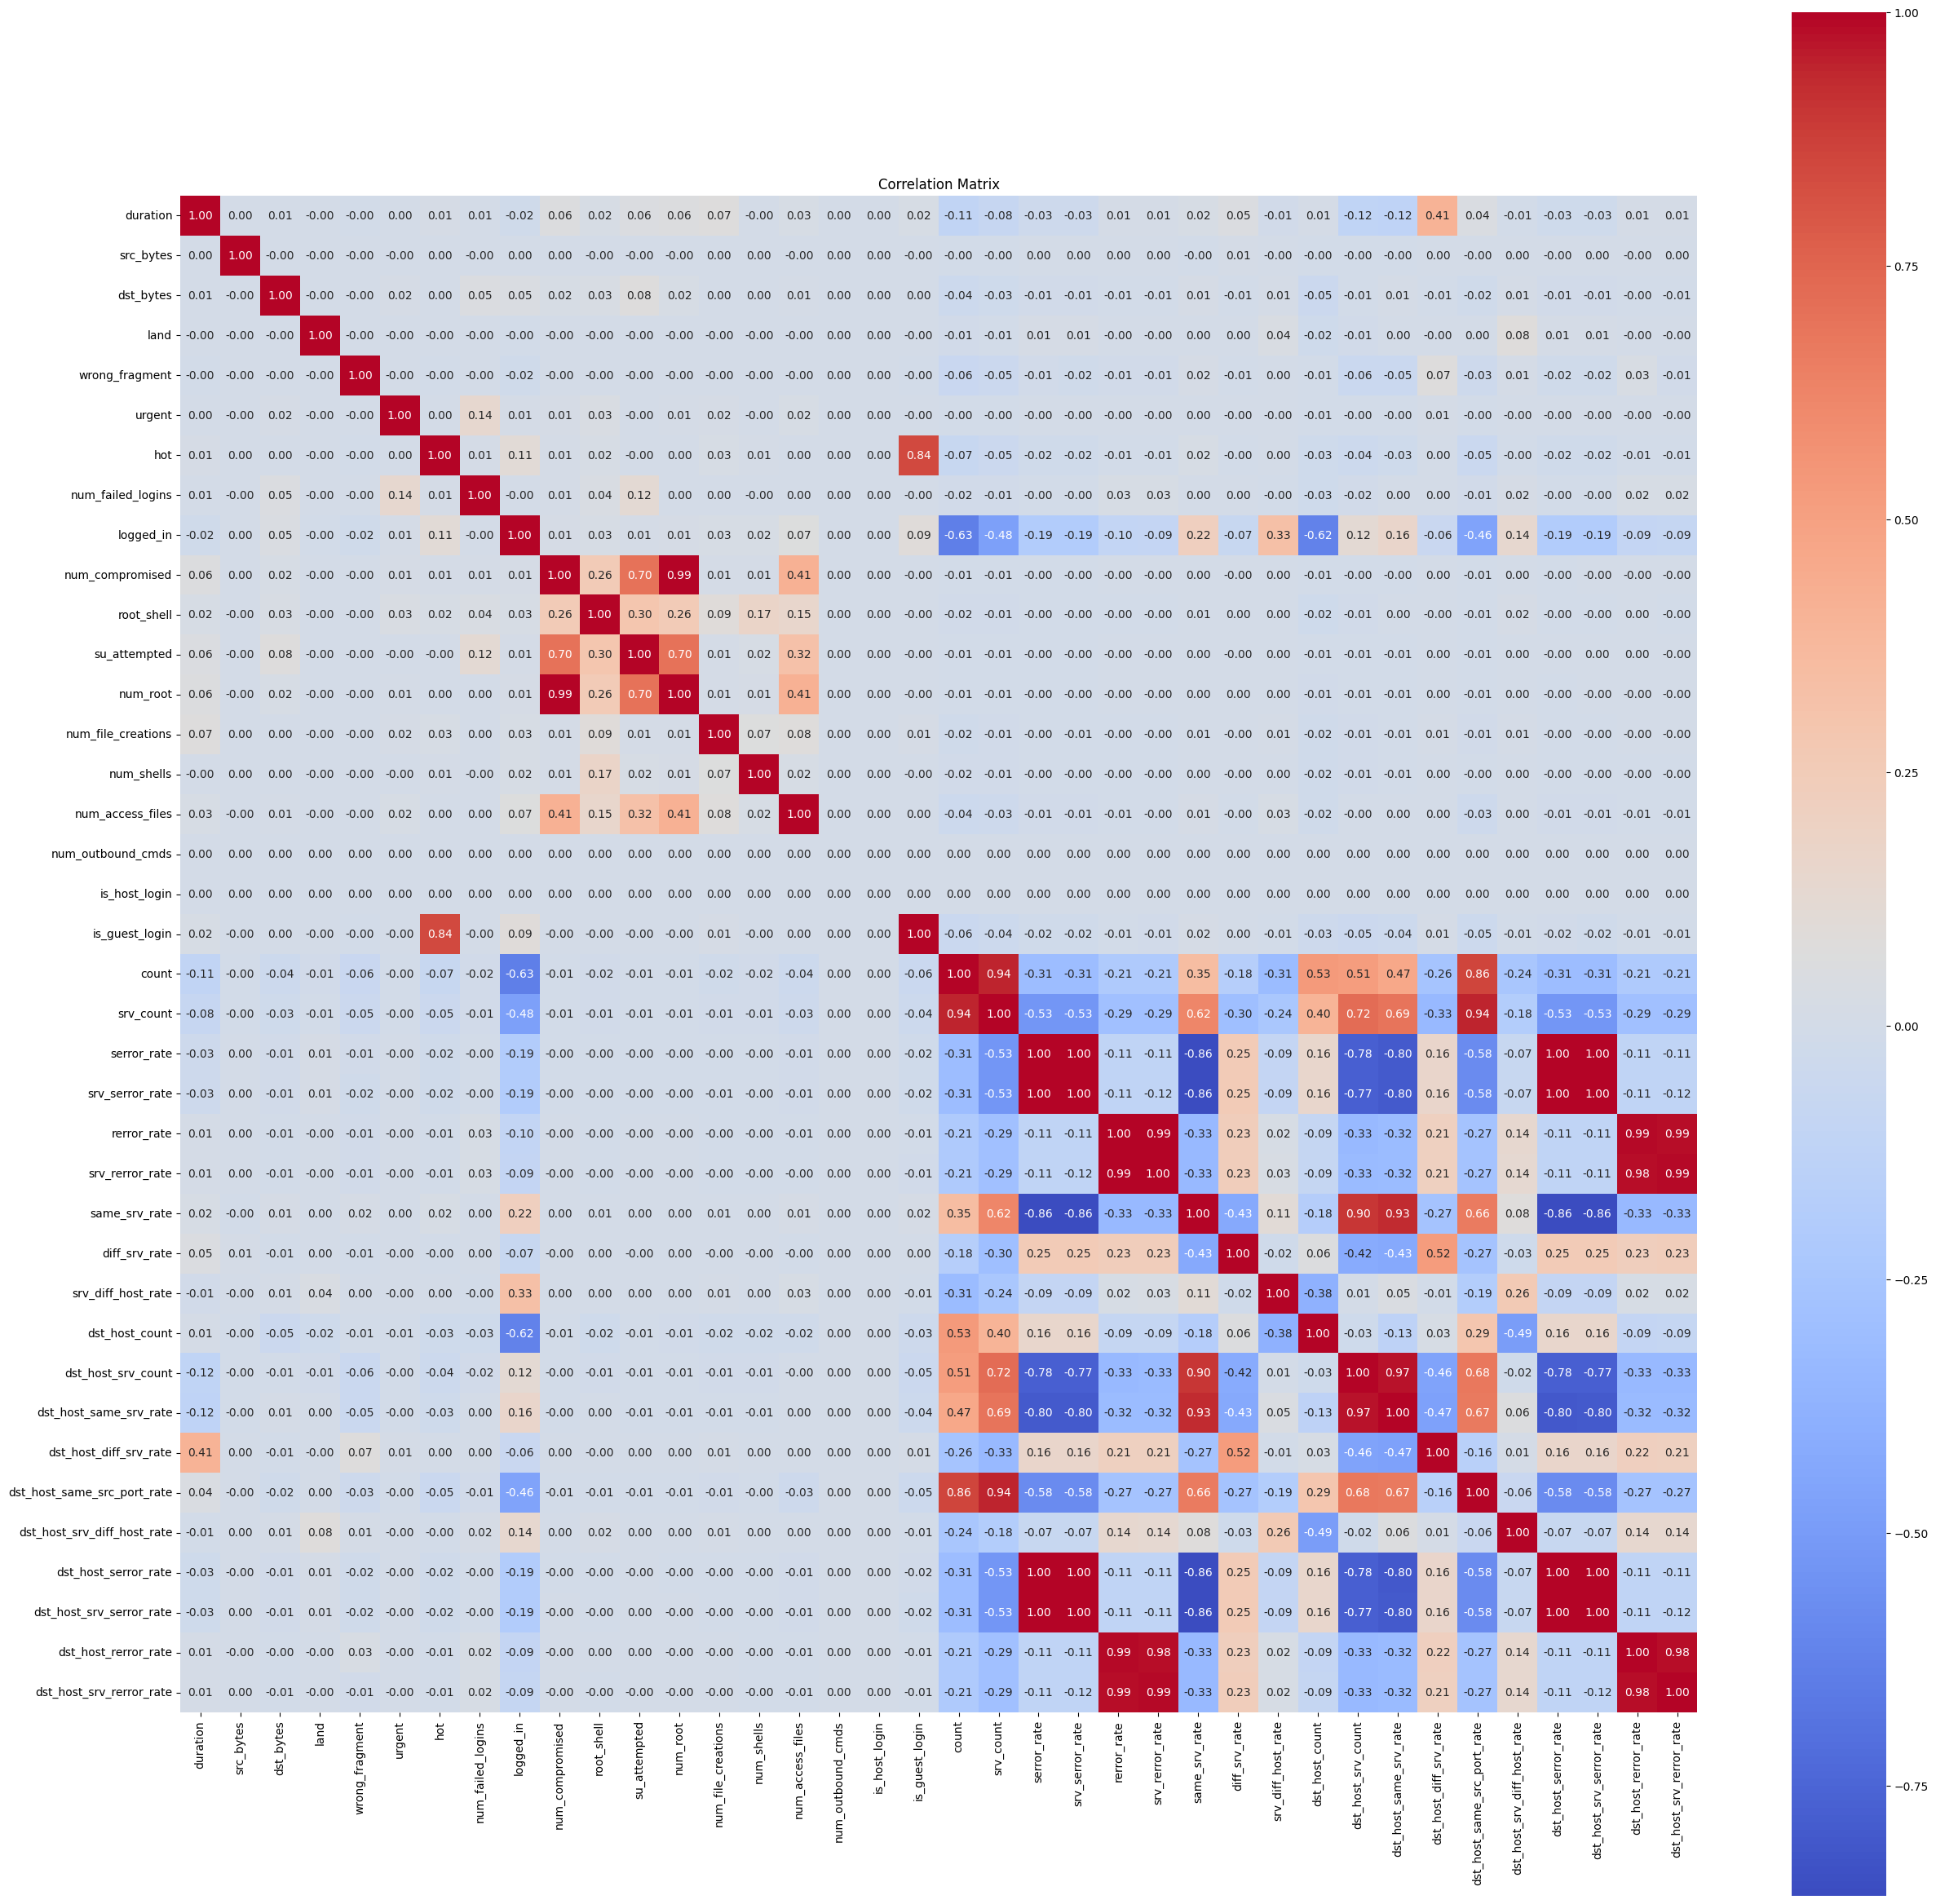

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(30, 30))

# Create a heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)

# Add title
plt.title('Correlation Matrix')

# Show the plot
plt.show()

In [ ]:
# Finding features with correlation value more than specified threshold value (bar=0.9)
# YOUR CODE HERE

# 1. Unstack the correlation matrix to get feature pairs
corr_pairs = correlation_matrix.unstack()

# 2. Convert the pairs into a DataFrame and sort by correlation value
sorted_corr_pairs = corr_pairs.sort_values(ascending=False)

# 3. Filter out self-correlations (where the feature is paired with itself)
filtered_corr_pairs = sorted_corr_pairs[sorted_corr_pairs.index.get_level_values(0) != sorted_corr_pairs.index.get_level_values(1)]

# 4. Remove duplicates by keeping only one of (A, B) and (B, A) pairs
filtered_corr_pairs = filtered_corr_pairs.reset_index()
filtered_corr_pairs['sorted_index'] = filtered_corr_pairs[['level_0', 'level_1']].apply(lambda x: tuple(sorted(x)), axis=1)
filtered_corr_pairs = filtered_corr_pairs.drop_duplicates(subset='sorted_index')

# 5. Remove the temporary sorted_index column and set the threshold
high_corr_pairs = filtered_corr_pairs[filtered_corr_pairs[0] > 0.9].drop(columns='sorted_index')

# Show the result
print(high_corr_pairs)

                     level_0                      level_1         0
0            srv_serror_rate     dst_host_srv_serror_rate  0.999304
2                serror_rate         dst_host_serror_rate  0.998673
4            srv_serror_rate                  serror_rate  0.998362
6       dst_host_serror_rate     dst_host_srv_serror_rate  0.998156
8                serror_rate     dst_host_srv_serror_rate  0.997849
10           srv_serror_rate         dst_host_serror_rate  0.997835
12           srv_rerror_rate                  rerror_rate  0.994731
14                  num_root              num_compromised  0.993828
16      dst_host_rerror_rate                  rerror_rate  0.986995
18           srv_rerror_rate     dst_host_srv_rerror_rate  0.986571
20  dst_host_srv_rerror_rate                  rerror_rate  0.985200
22      dst_host_rerror_rate     dst_host_srv_rerror_rate  0.984804
24           srv_rerror_rate         dst_host_rerror_rate  0.982166
26        dst_host_srv_count       dst_host_same

### Analysis report (1 points)

* Find the ratio of attacked transactions vs normal transactions

    Hint: encode instrusion_type column by replacing normal with 1 and all other with 0

* Describe the statistics of attacked and normal transactions
    
    Hint: Min, Max, Mean
    
* Select any two features that influence the intrusion_type and visualize the scatter plot to see the separation of normal and attacked

In [ ]:
dfNetDetect.show(5)

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate

In [ ]:
# YOUR CODE HERE
df = dfNetDetect.toPandas();
df['intrusion_types_encoded'] = df['intrusion_types'].apply(lambda x: 1 if x == 'normal.' else 0)

In [ ]:
dfNetDetectNew = dfNetDetect.withColumn("intrusion_types_encoded", when(col("intrusion_types") == 'normal.', 1).otherwise(0))

In [ ]:
dfNetDetectNew.show()

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+-----------------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv

In [ ]:
dfNetDetect['intrusion_types_encoded'] = dfNetDetect['intrusion_types'].apply(lambda x: 1 if x == 'normal.' else 0)

TypeError: 'Column' object is not callable

In [ ]:
dfNetDetect.show(5)

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate

In [ ]:
# YOUR CODE HERE
df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion_types,intrusion_types_encoded
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.,1
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,normal.,1
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.,1
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.,1
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.,1


In [ ]:
# YOUR CODE HERE
# Filter normal and attacked transactions
normal_transactions = df[df['intrusion_types_encoded'] == 1]
attacked_transactions = df[df['intrusion_types_encoded'] == 0]

In [ ]:
normal_transactions

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion_types,intrusion_types_encoded
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.,1
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,normal.,1
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.,1
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.,1
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,tcp,http,SF,310,1881,0,0,0,0,...,1.00,0.00,0.01,0.05,0.00,0.01,0.00,0.00,normal.,1
494017,0,tcp,http,SF,282,2286,0,0,0,0,...,1.00,0.00,0.17,0.05,0.00,0.01,0.00,0.00,normal.,1
494018,0,tcp,http,SF,203,1200,0,0,0,0,...,1.00,0.00,0.06,0.05,0.06,0.01,0.00,0.00,normal.,1
494019,0,tcp,http,SF,291,1200,0,0,0,0,...,1.00,0.00,0.04,0.05,0.04,0.01,0.00,0.00,normal.,1


In [ ]:
attacked_transactions

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion_types,intrusion_types_encoded
744,184,tcp,telnet,SF,1511,2957,0,0,0,3,...,1.00,0.00,1.00,0.67,0.00,0.00,0.00,0.00,buffer_overflow.,0
745,305,tcp,telnet,SF,1735,2766,0,0,0,3,...,1.00,0.00,0.50,0.50,0.00,0.00,0.00,0.00,buffer_overflow.,0
4049,79,tcp,telnet,SF,281,1301,0,0,0,2,...,1.00,0.00,1.00,0.30,0.00,0.00,0.00,0.10,loadmodule.,0
4113,25,tcp,telnet,SF,269,2333,0,0,0,0,...,0.03,0.06,0.01,0.00,0.00,0.00,0.00,0.00,perl.,0
7601,0,tcp,telnet,S0,0,0,0,0,0,0,...,1.00,0.00,0.20,0.33,1.00,0.83,0.00,0.00,neptune.,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490960,0,udp,private,SF,28,0,0,3,0,0,...,0.38,0.01,0.38,0.00,0.00,0.00,0.00,0.00,teardrop.,0
490961,0,udp,private,SF,28,0,0,3,0,0,...,0.38,0.01,0.38,0.00,0.00,0.00,0.00,0.00,teardrop.,0
490962,0,udp,private,SF,28,0,0,3,0,0,...,0.38,0.01,0.38,0.00,0.00,0.00,0.00,0.00,teardrop.,0
490963,0,udp,private,SF,28,0,0,3,0,0,...,0.39,0.01,0.39,0.00,0.00,0.00,0.00,0.00,teardrop.,0


In [ ]:
# Ratio of normal transactions to attacked transactions
normal_count = normal_transactions.shape[0]
attacked_count = attacked_transactions.shape[0]
total_count = normal_count + attacked_count

ratio = normal_count / attacked_count

print("Ratio of normal transactions to attacked transactions:", ratio)


Ratio of normal transactions to attacked transactions: 0.24519147155715412


In [ ]:
print(normal_count/total_count*100)

19.691065764410826


In [ ]:
print(attacked_count/total_count*100)

80.30893423558918


In [ ]:
print()

In [ ]:
dfNetDetect.show(5)

+--------+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|duration|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate|diff_srv_rate|srv_diff_host_rate

In [ ]:
#Describe the statistics of attacked and normal transactions
#Hint: Min, Max, Mean

df_statsNetDetect = dfNetDetect['duration', 'intrusion_types']
#df_statsNetDetect.show(5)




In [ ]:
dfNetDetec

In [ ]:
dfNetDetect.describe().show()

+-------+-----------------+-------------+-------+------+------------------+-----------------+--------------------+--------------------+--------------------+-------------------+--------------------+------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-----------------+-------------+--------------------+-----------------+------------------+-------------------+-------------------+-------------------+-------------------+------------------+--------------------+--------------------+------------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|summary|         duration|protocol_type|service|  flag|         src_bytes|        dst_bytes|                land|      wrong_fragment|              urgent|  

In [ ]:
dfNetDetect[dfNetDetect['intrusion_types'] == 'normal.'].describe().show()

+-------+------------------+-------------+-------+-----+------------------+-----------------+--------------------+--------------+--------------------+-------------------+--------------------+------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-----------------+-------------+--------------------+------------------+------------------+--------------------+--------------------+--------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|summary|          duration|protocol_type|service| flag|         src_bytes|        dst_bytes|                land|wrong_fragment|              urgent|            

In [ ]:
dfNetDetect[dfNetDetect['intrusion_types'] != 'normal.'].describe().show()

+-------+------------------+-------------+-------+------+------------------+------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------------+-------------+--------------------+------------------+------------------+-------------------+-------------------+--------------------+-------------------+------------------+--------------------+--------------------+------------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+---------------+
|summary|          duration|protocol_type|service|  flag|         src_bytes|         dst_bytes|                land|      wrong_fragment|              u

In [ ]:
#Select any two features that influence the intrusion_type and visualize the scatter plot to see the separation of normal and attacked

In [ ]:
!pip install handyspark

In [ ]:
!pip install --upgrade numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 78.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.6.1 requires numpy<2.0a0,>=1.23, but you have numpy 2.1.2 which is incompatible.
cupy-cuda12x 12.2.0 requires numpy<1.27,>=1.20, but you have numpy 2.1.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.1.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.1.2 which is incompatible.
pytensor 2.25.4 requires numpy<2,>=1.17.0, but you have numpy 2.1.2 which is incompatible.
rmm-cu12 24.6.0 requires numpy<2.0a0,>=1.23, but you hav

In [ ]:
!pip install --upgrade handyspark

In [ ]:
#df['src_bytes'] = df['src_bytes'].astype(int)

In [ ]:
df['src_bytes'].max()

'999'

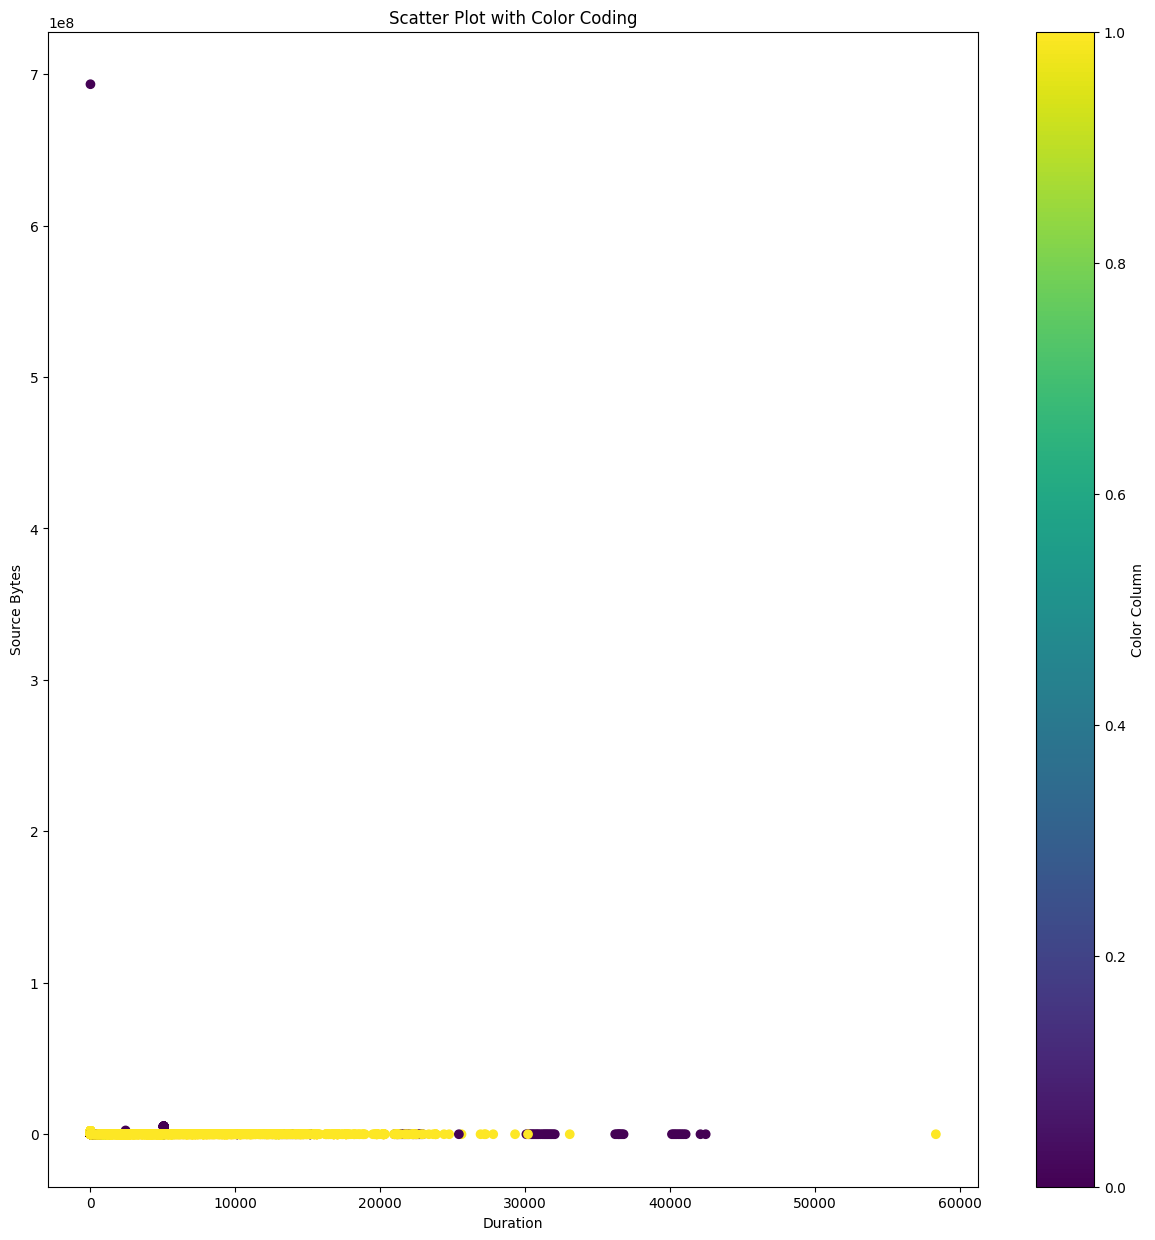

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame
# data = {
#     'x_column': [1, 2, 3, 4, 5],
#     'y_column': [10, 20, 25, 30, 40],
#     'color_column': [100, 200, 300, 400, 500]
# }
# df = pd.DataFrame(data)

# Create scatter plot
plt.figure(figsize=(15, 15))

# Convert Spark dataframe to handy
from pyspark.sql.functions import *
from pyspark.sql.types import *

#from handyspark import *
#dfHandy = dfNetDetectNew.toHandy()

df['duration'] = df['duration'].astype(int)
df['src_bytes'] = df['src_bytes'].astype(int)

plt.scatter(df['duration'], df['src_bytes'], c=df['intrusion_types_encoded'], cmap='viridis')

# Add color bar
plt.colorbar(label='Color Column')

# Add labels and title
plt.xlabel('Duration')
plt.ylabel('Source Bytes')
plt.title('Scatter Plot with Color Coding')

# Show plot
plt.show()


In [ ]:
srv_serror_rate     dst_host_srv_serror_rate

In [ ]:
high_corr_pairs.iloc[0, 1] #, high_corr_pairs.iloc[0]['level_1']

'dst_host_srv_serror_rate'

In [ ]:
high_corr_pairs.iloc[1, 0], high_corr_pairs.iloc[1, 1]

('serror_rate', 'dst_host_serror_rate')

In [ ]:
high_corr_pairs.iloc[1]['level_0'], high_corr_pairs.iloc[1]['level_1']

('serror_rate', 'dst_host_serror_rate')

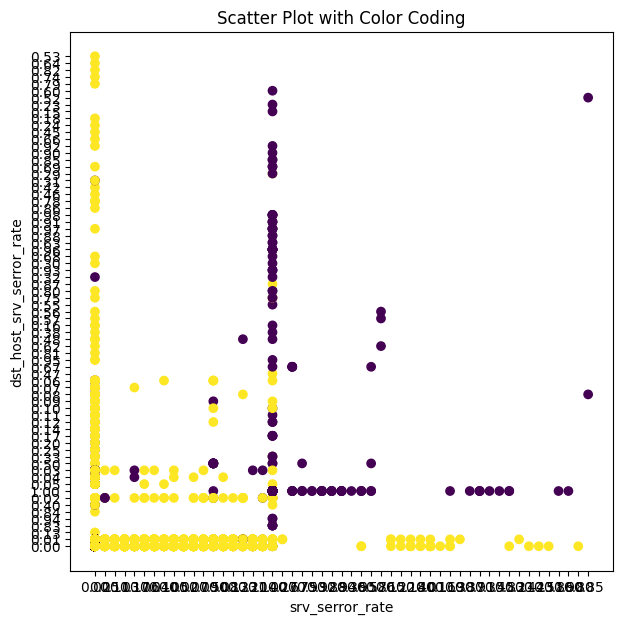

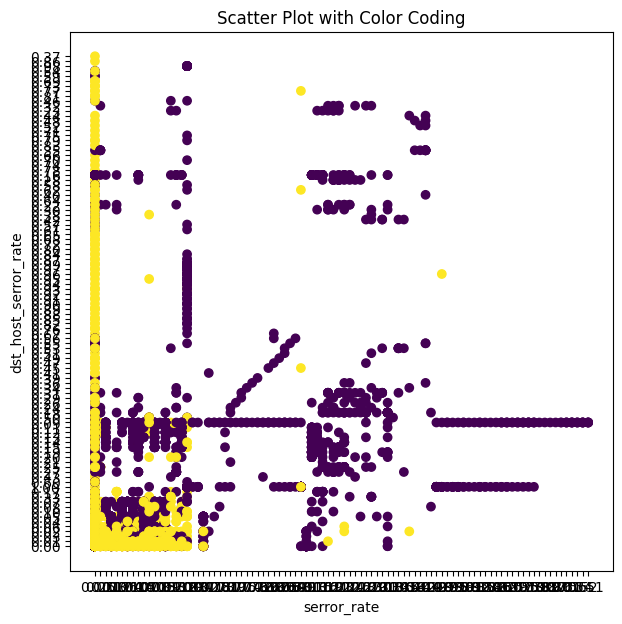

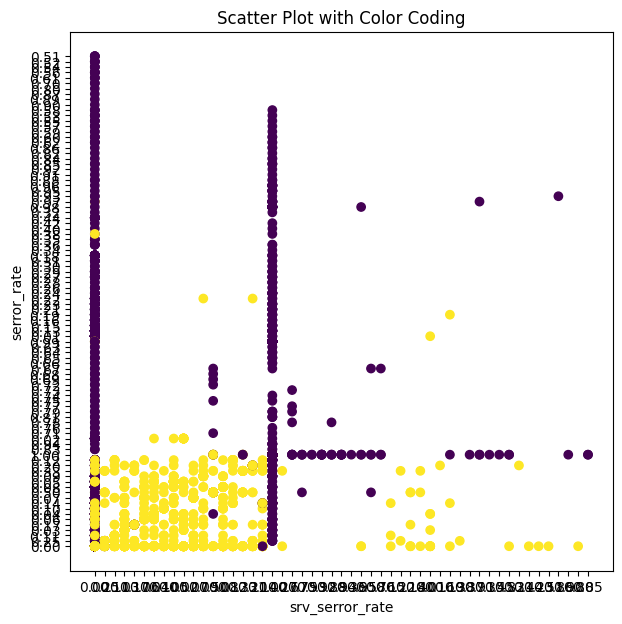

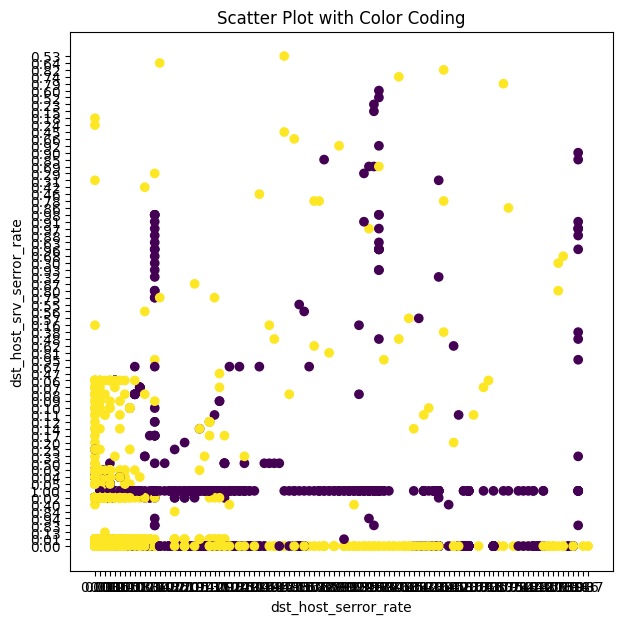

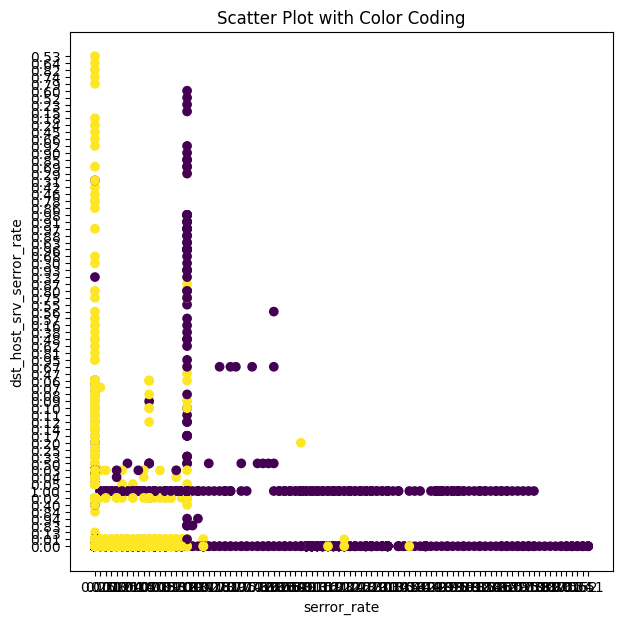

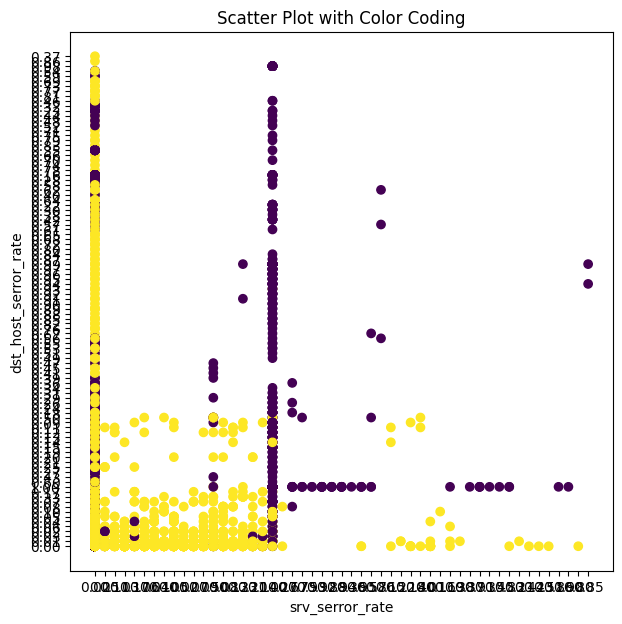

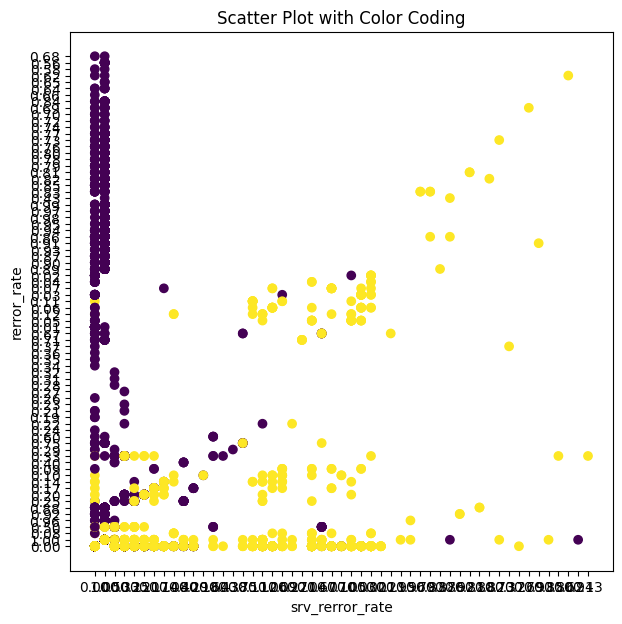

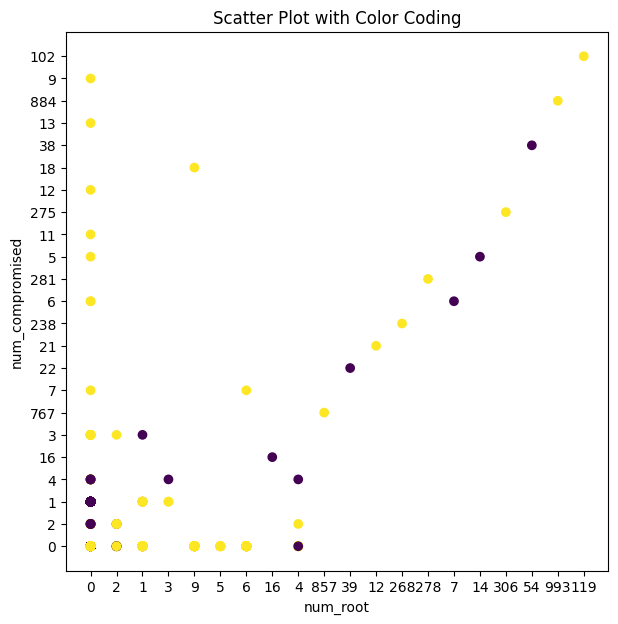

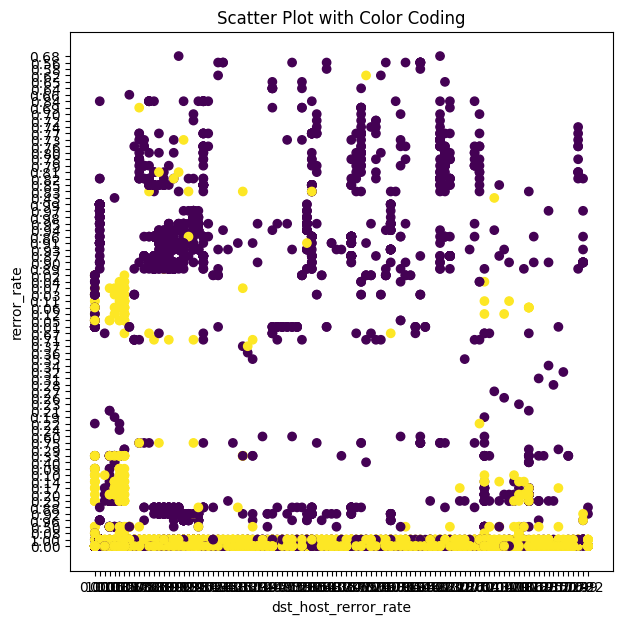

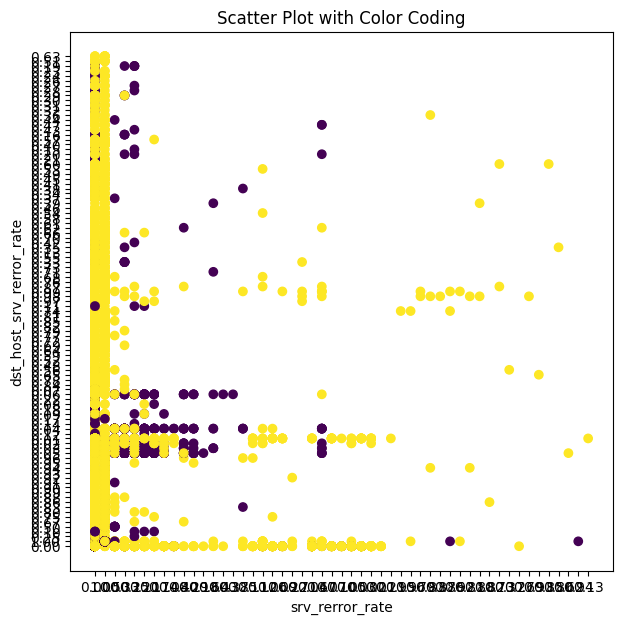

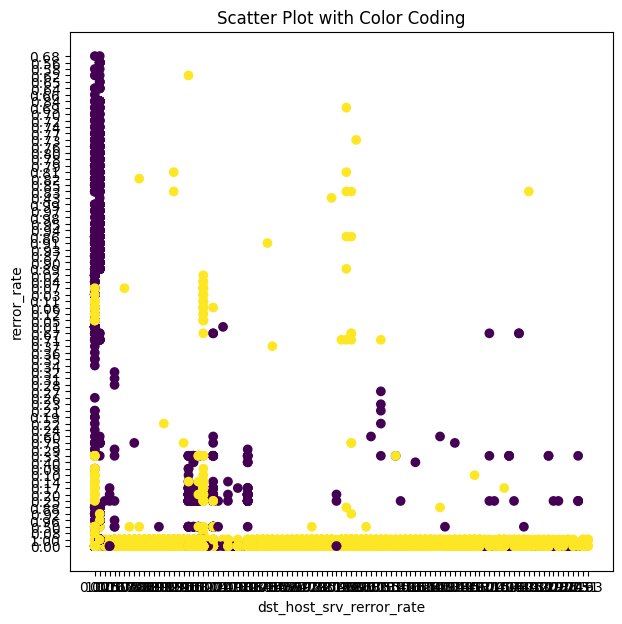

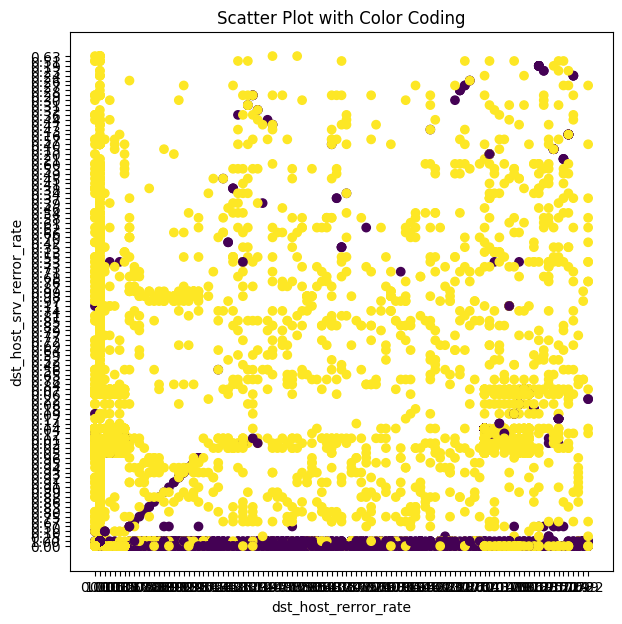

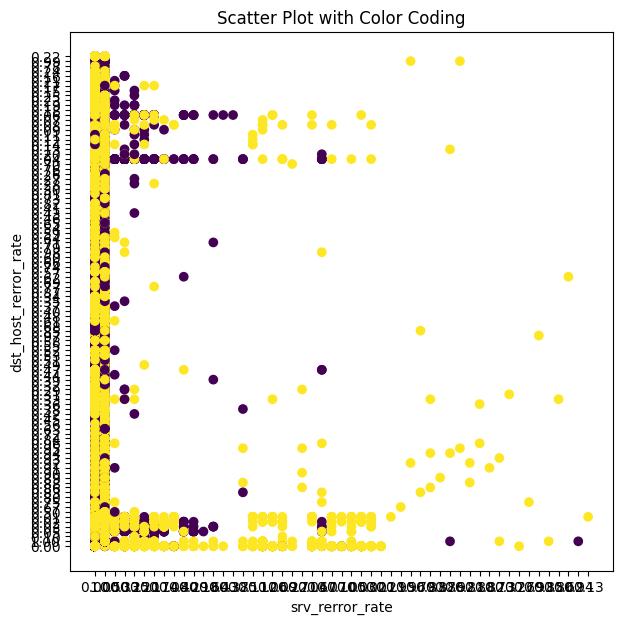

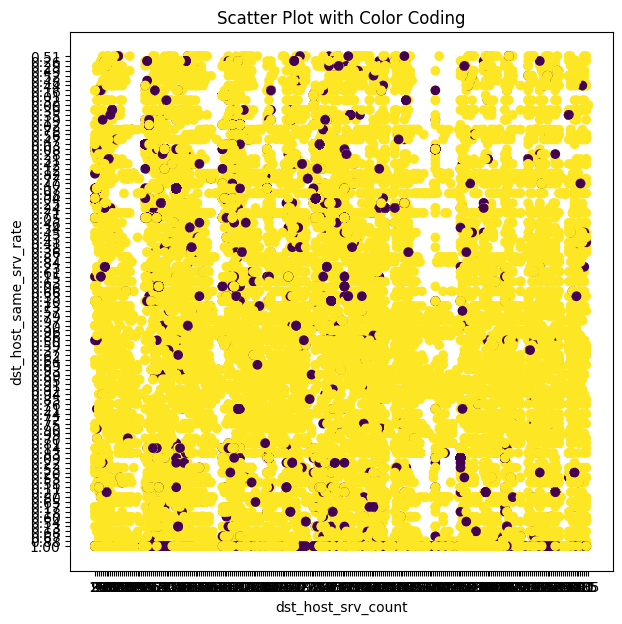

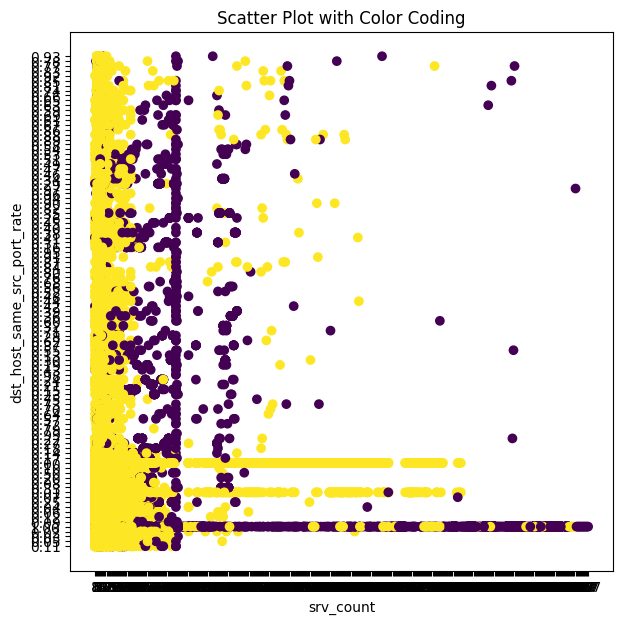

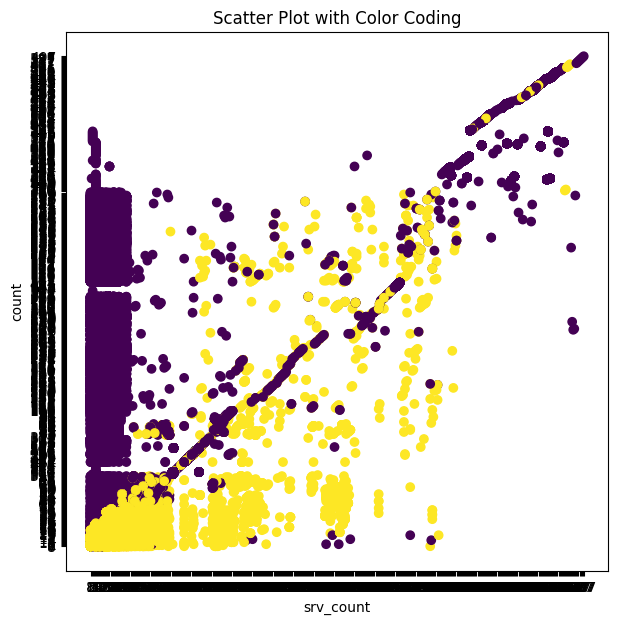

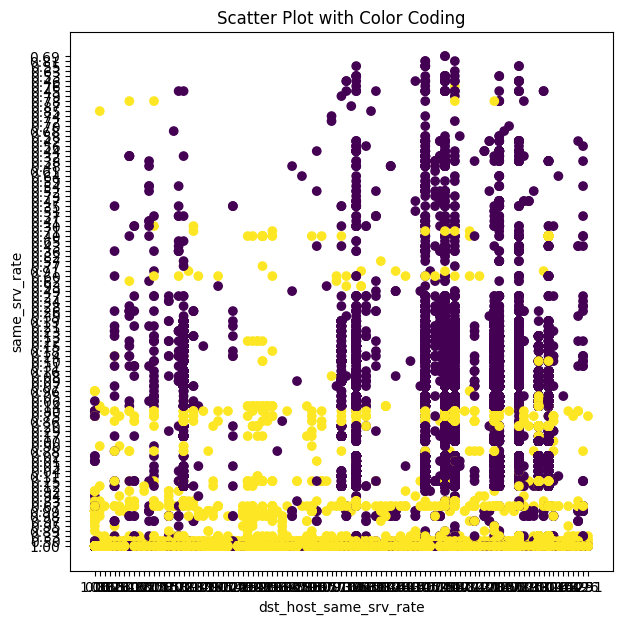

In [ ]:
# Create scatter plot
#plt.figure(figsize=(7, 7))

# Convert Spark dataframe to handy
from pyspark.sql.functions import *
from pyspark.sql.types import *

for i in range(len(high_corr_pairs)):
    plt.figure(figsize=(7, 7))
    plt.scatter(df[high_corr_pairs.iloc[i,0]], df[high_corr_pairs.iloc[i,1]], c=df['intrusion_types_encoded'], cmap='viridis')

    plt.xlabel(high_corr_pairs.iloc[i,0])
    plt.ylabel(high_corr_pairs.iloc[i,1])
    plt.title('Scatter Plot with Color Coding')

    # Show plot
    plt.show()

In [ ]:
df['src_bytes'].max()

693375640

In [ ]:
df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion_types,intrusion_types_encoded
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.,1
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,normal.,1
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.,1
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.,1
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.,1


In [ ]:
import sys
import numpy as np

# Monkey patch the problematic line in handyspark
if sys.version_info >= (3,):  # Python 3 and above
    import types

    def apply_patch(module):
        """Replaces np.bool with bool in the module."""
        module._MAPPING = {
            'string': str,
            'integer': int,
            'float': float,
            'double': float,
            'date': (
                "date"
            ),  # Handled specially later as it can be date or datetime
            'timestamp': "timestamp",  # Handled specially later
            'boolean': bool,  # Changed from np.bool to bool
            'binary': bytes,
            'byte': np.int8,
            'short': np.int16,
            'int': np.int32,
            'long': np.int64,
        }
        module.HandyTransform._MAPPING = module._MAPPING
        return module

    # Dynamically patch handyspark before it gets imported
    import importlib.util

    spec = importlib.util.find_spec("handyspark.sql.transform")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    sys.modules["handyspark.sql.transform"] = apply_patch(module)

# Now you can import handyspark
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import *
from pyspark.sql.types import *
from handyspark import *

# ... (rest of your code)

/usr/local/lib/python3.10/dist-packages/handyspark/sql/transform.py:9: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  'boolean': np.bool,


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations